C:\Users\karlw\AppData\Local\Temp\ipykernel_21932\2033063237.py:14: DtypeWarning: Columns (0: ichd3_4_K1, 1: comment_4_K1, 2: adverse2_a5_K1, 3: adverse3_a5_K1, 4: adverse1_a6_K1, 5: adverse2_a6_K1, 6: adverse3_a6_K1, 7: acute_name_a7_K1, 8: dosage_unit_a7_K1, 9: dosage_admin_a7_K1, 10: adverse1_a7_K1, 11: adverse2_a7_K1, 12: adverse3_a7_K1, 13: acute_name_a8_K1, 14: dosage_unit_a8_K1, 15: dosage_admin_a8_K1, 16: adverse1_a8_K1, 17: adverse2_a8_K1, 18: adverse3_a8_K1, 19: acute_name_a9_K1, 20: dosage_unit_a9_K1, 21: dosage_admin_a9_K1, 22: adverse1_a9_K1, 23: acute_name_a10_K1, 24: dosage_unit_a10_K1, 25: dosage_admin_a10_K1, 26: adverse1_a10_K1, 27: adverse2_a10_K1, 28: aborted_good_but_adverse_effect_fa_2_K1, 29: aborted_therapy_break_fa_2_K1, 30: aborted_not_needed_fa_2_K1, 31: aborted_good_but_adverse_effect_fa_3_K1, 32: aborted_therapy_break_fa_3_K1, 33: aborted_not_needed_fa_3_K1, 34: aborted_good_but_adverse_effect_fa_4_K1, 35: aborted_better_fa_4_K1, 36: aborted_therapy_break_f

Rows: 24497
Questionnaires: ['dass_depression_K10', 'dass_fear_K10', 'dass_stress_K10', 'midas_result_K10', 'gvas_result_K10', 'pgic_result_K10', 'chiq_result_K10', 'dass_depression_K11', 'dass_fear_K11', 'dass_stress_K11', 'midas_result_K11', 'gvas_result_K11', 'pgic_result_K11', 'chiq_result_K11', 'dass_depression_K12', 'dass_fear_K12', 'dass_stress_K12', 'midas_result_K12', 'gvas_result_K12', 'pgic_result_K12', 'chiq_result_K12', 'dass_depression_K13', 'dass_fear_K13', 'dass_stress_K13', 'midas_result_K13', 'gvas_result_K13', 'pgic_result_K13', 'chiq_result_K13', 'dass_depression_K14', 'dass_fear_K14', 'dass_stress_K14', 'midas_result_K14', 'gvas_result_K14', 'pgic_result_K14', 'chiq_result_K14', 'dass_depression_K15', 'dass_fear_K15', 'dass_stress_K15', 'midas_result_K15', 'gvas_result_K15', 'pgic_result_K15', 'chiq_result_K15', 'dass_depression_K16', 'dass_fear_K16', 'dass_stress_K16', 'midas_result_K16', 'gvas_result_K16', 'pgic_result_K16', 'chiq_result_K16', 'dass_depression_K1

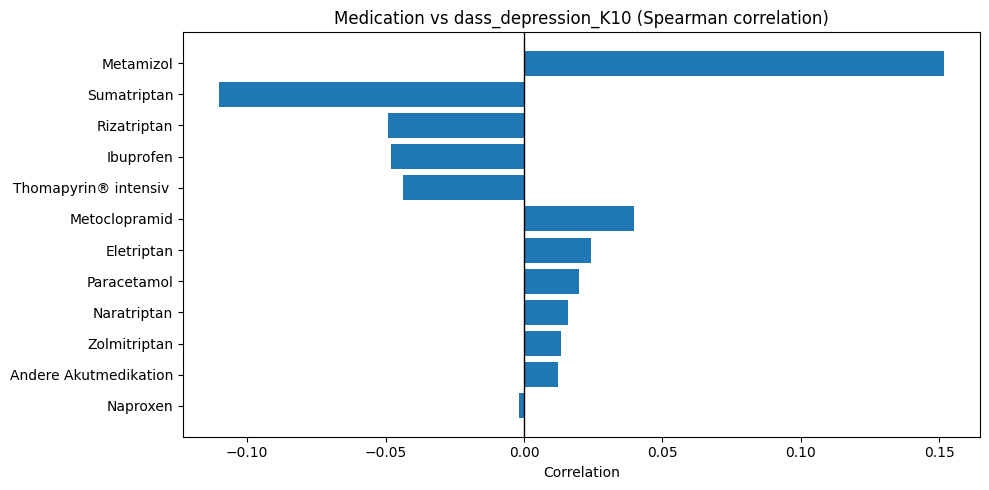

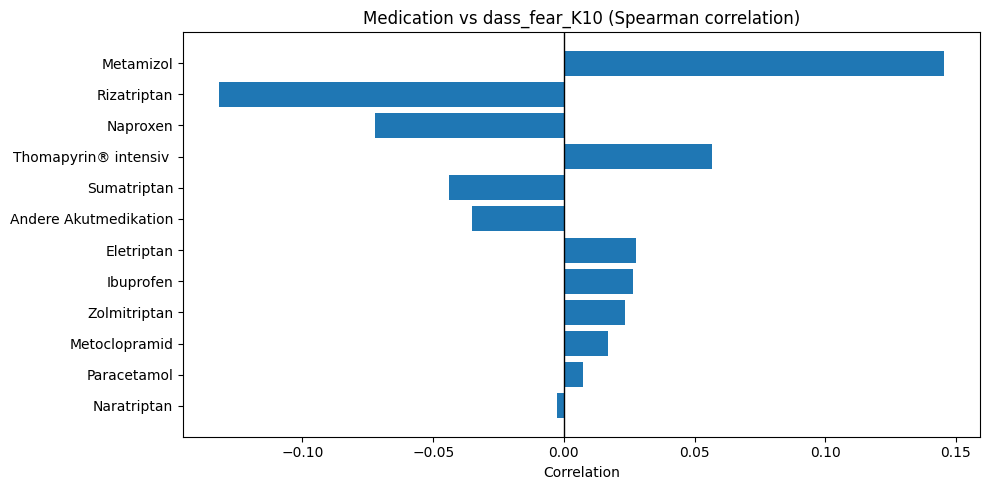

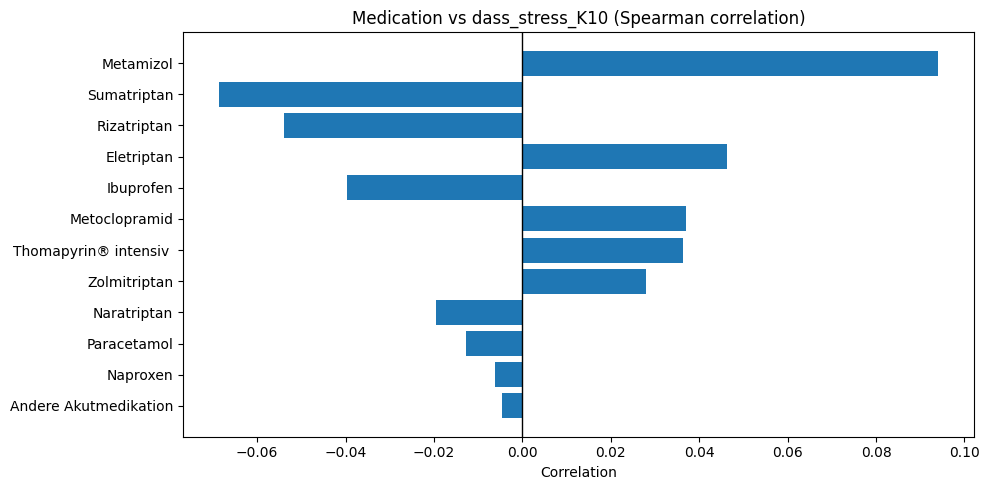

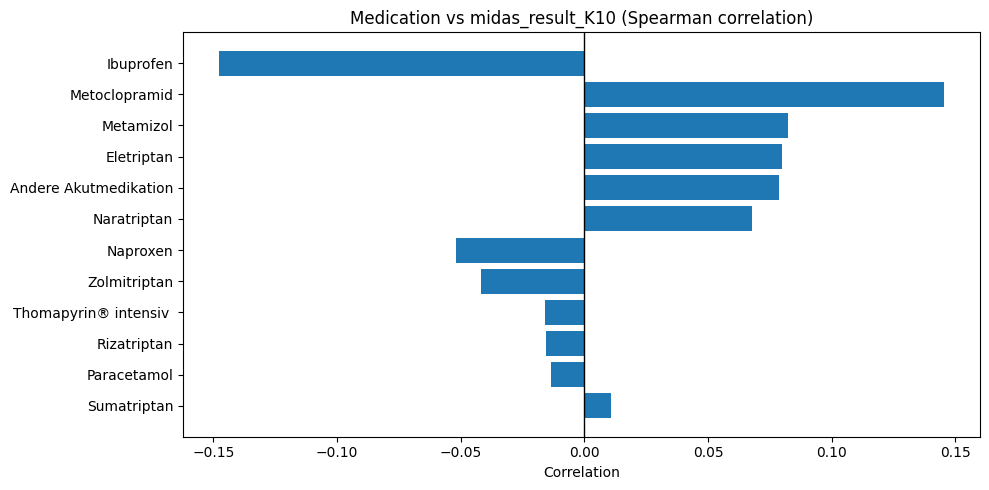

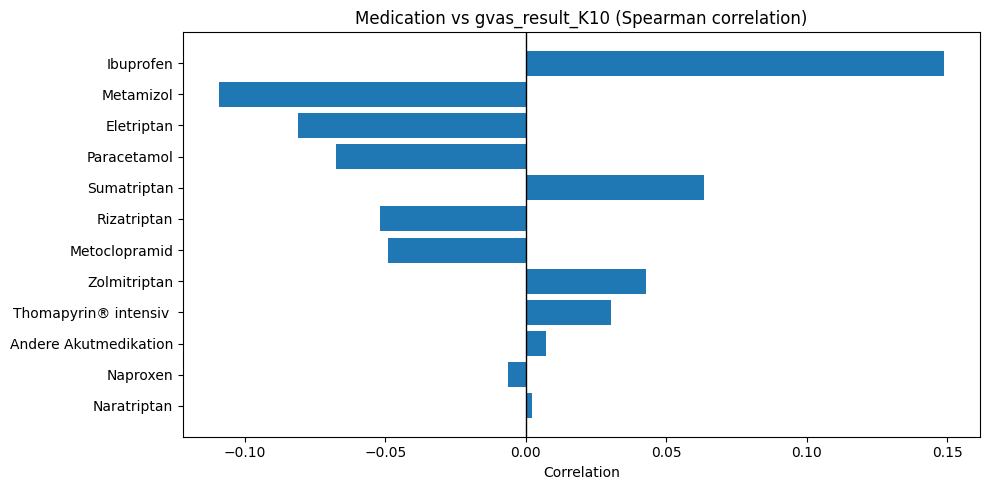

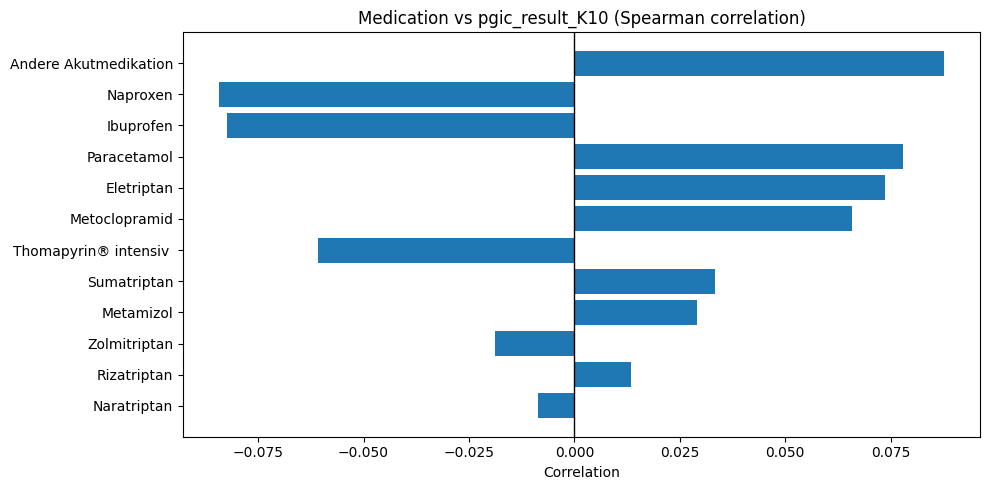

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import textwrap

# -----------------------
# LOAD DATA
# -----------------------

DATA_DIR = Path("./patienten-visiten")
csv_files = sorted(DATA_DIR.glob("Patients_V*.csv"))

dfs = [pd.read_csv(f, sep=";") for f in csv_files]
data = pd.concat(dfs, ignore_index=True)

print("Rows:", len(data))

# -----------------------
# CLEAN FUNCTION
# -----------------------

def clean_name(name):
    name = str(name)
    name = name.replace(",", ".")
    name = pd.Series([name]).str.replace(r"_K\d+$", "", regex=True).iloc[0]
    name = name.replace("_K", "")
    return name

def to_numeric(s):
    return pd.to_numeric(
        s.astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )

# -----------------------
# QUESTIONNAIRE COLUMNS
# -----------------------

score_cols = [c for c in data.columns if any(
    c.startswith(x) for x in [
        "midas_result",
        "dass_depression",
        "dass_fear",
        "dass_stress",
        "gvas_result",
        "pgic_result",
        "chiq_result"
    ]
)]

print("Questionnaires:", score_cols)

# -----------------------
# MEDICATION COLUMNS
# -----------------------

med_cols = [c for c in data.columns if c.startswith("acute_name_a")]

print("Medication columns:", len(med_cols))

# -----------------------
# CLEAN MEDICATION DATA
# -----------------------

med_data = data[med_cols].copy()

for c in med_cols:
    med_data[c] = med_data[c].apply(clean_name)

# reshape to long format
med_long = med_data.melt(value_name="med").dropna()
med_long = med_long[med_long["med"] != "nan"]

# one-hot encode medications
med_dummies = pd.get_dummies(med_long["med"])

# rebuild per patient row
med_matrix = med_dummies.groupby(med_long.index).max()

# align safely
med_matrix = med_matrix.reindex(data.index, fill_value=0).astype(float)

# -----------------------
# SCORE DATA (CLEAN)
# -----------------------

scores = data[score_cols].apply(to_numeric)

# -----------------------
# CORRELATION + PLOTS (DISPLAY ONLY)
# -----------------------

for score in score_cols:

    y = pd.to_numeric(scores[score], errors="coerce").astype(float)

    # align rows
    mask = ~y.isna()
    y = y[mask]
    X = med_matrix.loc[mask]

    correlations = []

    for med in X.columns:

        x = X[med]

        # skip rare meds
        if x.sum() < 5:
            continue

        # ensure clean numeric
        x_clean = pd.to_numeric(x, errors="coerce").fillna(0)

        y_clean = pd.to_numeric(y, errors="coerce")

        valid = ~(np.isnan(x_clean) | np.isnan(y_clean))

        if valid.sum() < 10:
            continue

        try:
            corr, _ = spearmanr(x_clean[valid], y_clean[valid])
        except Exception:
            continue

        if np.isnan(corr):
            continue

        correlations.append((med, corr))

    if not correlations:
        continue

    # sort strongest associations
    correlations = sorted(correlations, key=lambda x: abs(x[1]), reverse=True)[:15]

    meds, vals = zip(*correlations)
    meds_wrapped = [textwrap.fill(str(m), width=20) for m in meds]

    # -----------------------
    # PLOT
    # -----------------------

    plt.figure(figsize=(10, 8))
    bars = plt.barh(meds_wrapped[::-1], vals[::-1], color="lightgreen")
    plt.axvline(0, color="black", linewidth=1)
    plt.title(f"Medication vs {score} (Spearman correlation)", fontsize=14)
    plt.xlabel("Correlation")

    for i, bar in enumerate(bars):
        width = bar.get_width()
        ha = 'left' if width >= 0 else 'right'
        offset = 0.01 if width >= 0 else -0.01
        plt.text(width + offset, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center', ha=ha)

    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr
import re

# ============================================================
# LOAD DATA
# ============================================================

DATA_DIR = Path("./patienten-visiten")

csv_files = sorted(DATA_DIR.glob("Patients_V*.csv"))

dfs = [pd.read_csv(f, sep=";") for f in csv_files]
data = pd.concat(dfs, ignore_index=True)

print("Rows:", len(data))

# ============================================================
# HELPERS
# ============================================================

def clean_name(name):
    if pd.isna(name):
        return np.nan

    name = str(name)

    name = name.replace(",", ".")

    # remove trailing _K1, _K2, ...
    name = re.sub(r"_K\d+$", "", name)

    # remove trailing _K
    name = re.sub(r"_K$", "", name)

    return name.strip()


def to_numeric(series):
    return pd.to_numeric(
        series.astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )


C:\Users\karlw\AppData\Local\Temp\ipykernel_21932\1589379021.py:16: DtypeWarning: Columns (0: ichd3_4_K1, 1: comment_4_K1, 2: adverse2_a5_K1, 3: adverse3_a5_K1, 4: adverse1_a6_K1, 5: adverse2_a6_K1, 6: adverse3_a6_K1, 7: acute_name_a7_K1, 8: dosage_unit_a7_K1, 9: dosage_admin_a7_K1, 10: adverse1_a7_K1, 11: adverse2_a7_K1, 12: adverse3_a7_K1, 13: acute_name_a8_K1, 14: dosage_unit_a8_K1, 15: dosage_admin_a8_K1, 16: adverse1_a8_K1, 17: adverse2_a8_K1, 18: adverse3_a8_K1, 19: acute_name_a9_K1, 20: dosage_unit_a9_K1, 21: dosage_admin_a9_K1, 22: adverse1_a9_K1, 23: acute_name_a10_K1, 24: dosage_unit_a10_K1, 25: dosage_admin_a10_K1, 26: adverse1_a10_K1, 27: adverse2_a10_K1, 28: aborted_good_but_adverse_effect_fa_2_K1, 29: aborted_therapy_break_fa_2_K1, 30: aborted_not_needed_fa_2_K1, 31: aborted_good_but_adverse_effect_fa_3_K1, 32: aborted_therapy_break_fa_3_K1, 33: aborted_not_needed_fa_3_K1, 34: aborted_good_but_adverse_effect_fa_4_K1, 35: aborted_better_fa_4_K1, 36: aborted_therapy_break_f

In [ ]:
# ============================================================
# FIND QUESTIONNAIRE COLUMNS
# ============================================================

questionnaire_prefixes = [
    "midas_result",
    "dass_depression",
    "dass_fear",
    "dass_stress",
    "gvas_result",
    "pgic_result",
    "chiq_result"
]

questionnaire_groups = {}

for col in data.columns:

    for prefix in questionnaire_prefixes:

        if re.match(fr"^{prefix}_K\d+$", col):

            questionnaire_groups.setdefault(prefix, []).append(col)

# sort K columns numerically
for q in questionnaire_groups:

    questionnaire_groups[q] = sorted(
        questionnaire_groups[q],
        key=lambda x: int(re.search(r"_K(\d+)$", x).group(1))
    )

print("\nQuestionnaires found:")

for q, cols in questionnaire_groups.items():
    print(f"{q}: {len(cols)} visits")

# ============================================================
# COMBINE QUESTIONNAIRE K VALUES
# ============================================================

combined_scores = {}

for questionnaire, cols in questionnaire_groups.items():

    combined_scores[questionnaire] = (
        data[cols]
        .apply(to_numeric)
        .mean(axis=1)
    )


In [4]:
# ============================================================
# FIND MEDICATION COLUMNS
# ============================================================

med_cols = [
    c for c in data.columns
    if c.startswith("acute_name_a")
]

print("\nMedication columns:", len(med_cols))

# ============================================================
# BUILD MEDICATION MATRIX
# ============================================================

med_matrix = pd.DataFrame(index=data.index)

all_meds = set()

for col in med_cols:

    meds = data[col].apply(clean_name)

    unique_meds = meds.dropna().unique()

    all_meds.update(unique_meds)

all_meds = sorted(all_meds)

print("Unique medications:", len(all_meds))

# one-hot encoding
for med in all_meds:

    med_matrix[med] = 0

for col in med_cols:

    meds = data[col].apply(clean_name)

    for med in all_meds:

        mask = meds == med

        med_matrix.loc[mask, med] = 1

# force numeric
med_matrix = med_matrix.astype(float)


In [5]:
# ============================================================
# CORRELATION + PLOTS
# ============================================================

MIN_MED_OCCURRENCES = 5

for questionnaire, y in combined_scores.items():

    print(f"\n{'='*60}")
    print(questionnaire)
    print('='*60)

    y = pd.to_numeric(y, errors="coerce")

    correlations = []

    for med in med_matrix.columns:

        x = med_matrix[med]

        # skip very rare medications
        if x.sum() < MIN_MED_OCCURRENCES:
            continue

        valid = ~(x.isna() | y.isna())

        if valid.sum() < 10:
            continue

        try:
            corr, p = spearmanr(
                x[valid].astype(float),
                y[valid].astype(float)
            )

            if np.isnan(corr):
                continue

            correlations.append(
                {
                    "medication": med,
                    "correlation": corr,
                    "p_value": p,
                    "n": int(valid.sum())
                }
            )

        except Exception:
            continue

    if len(correlations) == 0:

        print("No valid correlations found.")
        continue

    corr_df = pd.DataFrame(correlations)

    corr_df["abs_corr"] = corr_df["correlation"].abs()

    corr_df = corr_df.sort_values(
        "abs_corr",
        ascending=False
    )

    top_n = min(20, len(corr_df))

    plot_df = corr_df.head(top_n)

    print(
        plot_df[
            ["medication", "correlation", "p_value"]
        ].round(4)
    )



dass_depression
                                   medication  correlation  p_value
20                                  Metamizol       0.0647   0.0000
4                       Andere Akutmedikation       0.0448   0.0000
34                                Rizatriptan      -0.0329   0.0000
9                                  Diclofenac       0.0328   0.0000
2                          Acetylsalicylsäure       0.0319   0.0000
10                              Dimenhydrinat       0.0307   0.0000
43                                    Tilidin       0.0302   0.0001
35                                 Sauerstoff       0.0240   0.0014
32                Paracetamol/Ibuprofen Acino       0.0205   0.0062
38  Suvexx® (Sumatriptan/Naproxen 85mg/500mg)      -0.0190   0.0110
19                                 Lasmiditan      -0.0186   0.0128
47                                   Tramadol       0.0184   0.0137
3                                 Almotriptan      -0.0163   0.0295
24                             

C:\Users\karlw\AppData\Local\Temp\ipykernel_21932\3762607140.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\karlw\AppData\Local\Temp\ipykernel_21932\3762607140.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\karlw\AppData\Local\Temp\ipykernel_21932\3762607140.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\karlw\AppData\Local\Temp\ipykernel_21932\3762607140.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\karlw\AppData\Local\Temp\ipykernel_21932\3762607140.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\karlw\AppData\Local\Temp\ipykernel_21932\3762607140.py:31: Constan

In [ ]:
for questionnaire, y in combined_scores.items():

    print("\n" + "="*60)
    print("QUESTIONNAIRE:", questionnaire)
    print("="*60)

    y = pd.to_numeric(y, errors="coerce")

    print("Y non-null:", y.notna().sum())

    correlations = []

    for med in med_matrix.columns:

        x = med_matrix[med]

        # basic stats
        x_sum = x.sum()
        y_valid = ~(x.isna() | y.isna())
        n = y_valid.sum()

        # DEBUG OUTPUT (IMPORTANT)
        if x_sum < 5:
            continue

        if n < 10:
            continue

        try:
            corr, p = spearmanr(
                x[y_valid].astype(float),
                y[y_valid].astype(float)
            )

            if np.isnan(corr):
                continue

            correlations.append((med, corr))

        except Exception as e:
            print(f"FAILED {med}: {e}")

    print("Valid correlations found:", len(correlations))

    if len(correlations) == 0:
        print("NO DATA FOR PLOT → check missing values / overlap")
        continue

    correlations = sorted(
        correlations,
        key=lambda x: abs(x[1]),
        reverse=True
    )[:20]

    meds, vals = zip(*correlations)
    meds_wrapped = [textwrap.fill(str(m), width=25) for m in meds]

    plt.figure(figsize=(12, max(8, len(meds) * 0.5)))

    bars = plt.barh(meds_wrapped[::-1], vals[::-1], color="lightblue")

    plt.axvline(0, linestyle="--", color="black", alpha=0.5)

    plt.title(f"{questionnaire}", fontsize=16)
    plt.xlabel("Spearman correlation")

    for bar in bars:
        width = bar.get_width()
        ha = 'left' if width >= 0 else 'right'
        offset = 0.01 if width >= 0 else -0.01
        plt.text(width + offset, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center', ha=ha)

    plt.tight_layout()

    import os

    SAVE_DIR = "correlation_plots"
    os.makedirs(SAVE_DIR, exist_ok=True)

    filename = f"{questionnaire}_medication_correlation.png"
    filepath = os.path.join(SAVE_DIR, filename)

    plt.savefig(filepath, dpi=200, bbox_inches="tight")
    print("Saved:", filepath)

    plt.show()